In [1]:
from sklearn.pipeline import make_pipeline,Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from market_data.market_data import get_daily_stats
import os
import perspective
%matplotlib inline

In [2]:
fname = 'c:/temp/simdd_trade_2_1_2024'
sim = pd.read_parquet(fname)
#sim = pd.read_parquet('c:/temp/simdd_trade')
sim['date'] = pd.to_datetime(sim.date)
for col in 'ar_vol ar_beta ADV ADVD'.split():
    sim[col].fillna((sim[col].mean()), inplace=True)
sim['abs_prev_signal'] = sim.prev_signal.abs()
sim.reset_index(drop=False,inplace=True)
sim.sort_values(['sym','date'],inplace=True)


In [3]:
fname_by_trade = f'{fname}_bytrade_et'
if os.path.exists(fname_by_trade) or False:
    print(f'Reading {fname_by_trade}')
    byTrade = pd.read_parquet(fname_by_trade)
    byTrade['first_date'] = pd.to_datetime(byTrade.first_date)
    byTrade['last_date'] = pd.to_datetime(byTrade.last_date)
    byTrade['abs_prev_signal'] = byTrade.prev_signal.abs()


else:
    #Enhance - for multi-day trades lets attach trade entry day and trade-exit days
    gb = sim.groupby('sym')
    sim['trade_id'] = gb.apply( lambda group: (group['pos'] != group['pos'].shift(1)).cumsum() ).droplevel(0)
    trade_aggs = {
        'date': ['first', 'last', len]
    }
    for c in ['alpha','gamma', 'beta', 'characteristic_time', 'sigma_equilibrium', 'signal',
           'prev_signal', 'ar_vol', 'ar_beta', 'ADV', 'ADVD', 'activity','pos' ]:
        trade_aggs [ c ] = [ 'first' ]
        
    def cumreturn(s):
        return (1+s).prod()-1

    def cumreturn_earlyterm(s):
        returns = (1+s).cumprod()-1
        for r in returns:
            if r < 0: #0 bps cut-off
                return r
        return r # last one
        
        
    for c in ['c2c', 'factor_c2c']:
        trade_aggs[c] = [ cumreturn ]
    trade_aggs['excess_c2c'] = [ cumreturn_earlyterm ]
    
    byTrade  = sim.groupby(['sym','trade_id']).agg(trade_aggs).reset_index(drop=False)
    byTrade.columns = byTrade.columns.map(lambda x: f'{x[1]}_{x[0]}' if x[0]=='date' else x[0])
    byTrade['ew_return'] = byTrade['pos'] * byTrade['excess_c2c']
    byTrade['abs_prev_signal'] = byTrade.prev_signal.abs()
    byTrade.to_parquet(fname_by_trade,compression='gzip')



Reading c:/temp/simdd_trade_2_1_2024_bytrade_et


In [4]:
#Add quantiles for certain continuous varibales
##TODO CHANGE TO REFERENCE THE STATS ON DAY 0 OF TRADE ONLY
q= list(np.arange(0,1.,.1))
for c in  "alpha gamma beta ADV ADVD abs_prev_signal prev_signal activity ar_vol".split():    
    ##quantiles = sim[c].quantile(q+[1]).values
    labels = [str(int(10*s)) for s in q]
    byTrade[f'{c}_q']= pd.qcut( byTrade[c],q+[1],retbins=False,labels=labels)
    sim[f'{c}_q']= pd.qcut( sim[c],q+[1],retbins=False,labels=labels)

    ##print the resulting cuts
    #print(sim.groupby(f'{c}_q').agg( { c:[np.mean,np.min, np.max,len] } ))
byTrade.columns

Index(['sym', 'trade_id', 'first_date', 'last_date', 'len_date', 'alpha',
       'gamma', 'beta', 'characteristic_time', 'sigma_equilibrium', 'signal',
       'prev_signal', 'ar_vol', 'ar_beta', 'ADV', 'ADVD', 'activity', 'pos',
       'c2c', 'factor_c2c', 'excess_c2c', 'ew_return', 'abs_prev_signal',
       'alpha_q', 'gamma_q', 'beta_q', 'ADV_q', 'ADVD_q', 'abs_prev_signal_q',
       'prev_signal_q', 'activity_q', 'ar_vol_q'],
      dtype='object')

<AxesSubplot:>

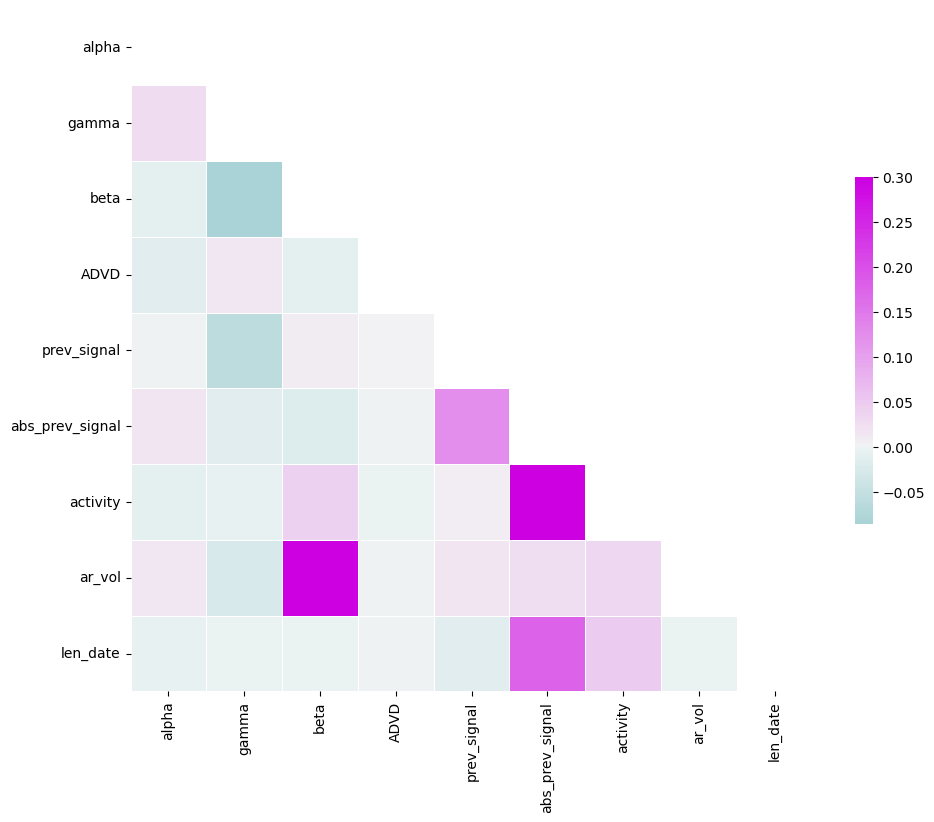

In [5]:
featdf = byTrade["alpha gamma beta ADVD prev_signal abs_prev_signal activity ar_vol len_date".split()]
corr = featdf.corr()
# Generate a mask for the upper triangle
mask = np.triu(np.ones_like(corr, dtype=bool))

# Set up the matplotlib figure
f, ax = plt.subplots(figsize=(11, 9))

# Generate a custom diverging colormap
cmap = sns.diverging_palette(200, 300, s=100, as_cmap=True)

# Draw the heatmap with the mask and correct aspect ratio
sns.heatmap(corr, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})


In [6]:
#Standalone return by quartile
features = 'alpha gamma beta ADVD ar_vol len_date'.split()
for feature in features:
    with pd.option_context('display.max_rows', 20,'display.float_format', '{:,.2f}'.format):
        col = feature if feature == 'len_date' else feature + '_q' 
        temps=byTrade.groupby([col]).agg({'ew_return':[np.mean,np.std,min,max,len],
                                      feature:[np.min,np.max]})
        temps[('ew_return','mean')]*=10000; temps[('ew_return','std')]*=10000 #bps
        temps[('ew_return','min')]*=10000; temps[('ew_return','max')]*=10000 #bps
        temps [('ew_return','std_err')] = temps[('ew_return','std')]/np.sqrt(temps[('ew_return','len')])
        print(feature)
        display(temps)


alpha


ew_return                                    alpha      ew_return
             mean    std       min       max     len   min  max   std_err
alpha_q                                                                  
0            0.73 190.39 -6,659.14  7,145.01  104547  0.50 0.89      0.59
1            1.01 178.02 -6,098.94  3,326.18  104537  0.89 0.94      0.55
2            2.27 175.12 -3,995.38 11,135.04  104546  0.94 0.97      0.54
3            1.59 179.69 -7,695.09 10,146.70  104542  0.97 1.00      0.56
4            2.08 174.27 -7,834.41  4,367.07  104539  1.00 1.03      0.54
5            3.04 175.81 -9,061.68  6,740.12  104546  1.03 1.06      0.54
6            2.87 168.12 -6,281.08  7,237.21  104542  1.06 1.09      0.52
7            3.29 170.14 -6,121.60  4,021.07  104539  1.09 1.12      0.53
8            3.43 165.08 -7,503.98  4,378.84  104538  1.12 1.17      0.51
9            5.08 170.80 -7,563.27  6,567.75  104541  1.17 1.64      0.53

gamma


ew_return                                    gamma       ew_return
             mean    std       min       max     len   min   max   std_err
gamma_q                                                                   
0            2.94 269.71 -7,700.10  7,237.21  104545 -0.01 -0.00      0.83
1            1.65 195.02 -7,695.09  4,463.09  104539 -0.00 -0.00      0.60
2            1.70 162.01 -4,157.74  4,049.72  104543 -0.00 -0.00      0.50
3            2.48 147.30 -7,563.27  3,604.37  104542 -0.00 -0.00      0.46
4            2.18 151.55 -6,568.46 10,146.70  104546 -0.00  0.00      0.47
5            2.31 134.77 -4,567.32  3,358.02  104536  0.00  0.00      0.42
6            2.41 145.37 -9,061.68 11,135.04  104542  0.00  0.00      0.45
7            3.13 143.56 -4,657.48  4,412.49  104544  0.00  0.00      0.44
8            2.57 155.57 -3,953.06  4,976.53  104538  0.00  0.00      0.48
9            4.01 200.06 -7,834.41  4,073.42  104542  0.00  0.01      0.62

beta


...

ew_return                                              ADVD   
            mean    std       min       max     len            min   
ADVD_q                                                               
0           3.35 204.95 -9,061.68  6,740.12  104542          90.02  \
1           2.49 172.90 -5,902.08  7,145.01  104542  17,158,984.00   
2           2.75 172.73 -3,706.24 10,146.70  104544  28,015,696.00   
3           2.08 180.52 -6,595.41  4,378.84  104539  39,697,556.00   
4           2.39 180.34 -6,568.46  4,412.49  104543  54,578,510.00   
5           2.96 173.37 -7,700.10  3,456.92  104542  74,759,470.00   
6           2.87 165.65 -4,567.32  6,567.75  104540 101,742,830.00   
7           2.42 165.63 -6,098.94  3,514.84  104541 140,182,130.00   
8           2.20 165.19 -7,834.41  7,237.21  104544 208,673,820.00   
9           1.88 163.59 -7,503.98 11,135.04  104540 378,242,200.00   

                          ew_return  
                      max   std_err  
ADVD_q                               
0           17,158,982.00      0.63  
1           28,015,562.00      0.53  
2           39,697,404.00      0.53  
3           54,578,504.00      0.56  
4           74,759,256.00      0.56  
5          101,742,530.00      0.54  
6          140,181,390.00      0.51  
7          208,673,380.00      0.51  
8          378,238,660.00      0.51  
9      378,504,540,000.00      0.51

ar_vol


ew_return                                    ar_vol      ew_return
              mean    std       min       max     len    min  max   std_err
ar_vol_q                                                                   
0             0.55  74.15 -1,734.73    999.97  104542   0.00 0.01      0.23
1             1.10  92.72 -1,953.92  2,404.25  104542   0.01 0.01      0.29
2             1.68 106.67 -3,344.88  1,535.99  104541   0.01 0.01      0.33
3             1.52 120.21 -3,808.98  1,711.81  104542   0.01 0.02      0.37
4             2.17 133.78 -3,167.16  3,326.18  104542   0.02 0.02      0.41
5             2.17 149.48 -3,771.60  3,281.32  104541   0.02 0.02      0.46
6             3.75 176.21 -5,948.35  3,383.52  104542   0.02 0.02      0.54
7             3.23 188.13 -3,995.38  4,641.13  104541   0.02 0.03      0.58
8             4.07 227.37 -6,659.14  4,976.53  104542   0.03 0.03      0.70
9             5.13 327.87 -9,061.68 11,135.04  104542   0.03 0.24      1.01

len_date


ew_return                                      len_date     ew_return
              mean      std       min       max     len      min max   std_err
len_date                                                                      
1            44.37   116.40 -2,117.94 11,135.04  751038        1   1      0.13
2           -47.18   180.01 -9,061.68  4,641.13  166354        2   2      0.44
3          -126.96   219.63 -5,418.23  3,167.98   63673        3   3      0.87
4          -183.52   269.49 -5,967.64  1,859.17   31938        4   4      1.51
5          -229.70   309.89 -6,411.98  2,404.25   16164        5   5      2.44
6          -268.72   348.94 -7,503.98  1,325.98    8072        6   6      3.88
7          -326.10   438.32 -6,659.14    629.63    3921        7   7      7.00
8          -354.41   448.68 -4,658.33    774.51    2065        8   8      9.87
9          -417.93   490.61 -5,144.10     44.22    1074        9   9     14.97
10         -414.16   510.64 -4,048.65     17.05     535       10  10     22.08
11         -442.81   638.54 -6,281.08     10.43     282       11  11     38.02
12         -533.30   743.58 -3,632.60    129.82     143       12  12     62.18
13         -692.12 1,244.76 -7,695.09    -12.52      82       13  13    137.46
14         -798.73 1,276.18 -7,563.27     33.81      40       14  14    201.78
15         -559.94   659.59 -2,338.11    -27.53      19       15  15    151.32
16         -821.36   808.12 -2,503.70    -12.22       8       16  16    285.71
17         -385.33   393.99   -836.28   -107.77       3       17  17    227.47
18       -1,035.86 1,180.90 -2,890.79     11.23       5       18  18    528.11
19         -468.97      NaN   -468.97   -468.97       1       19  19       NaN

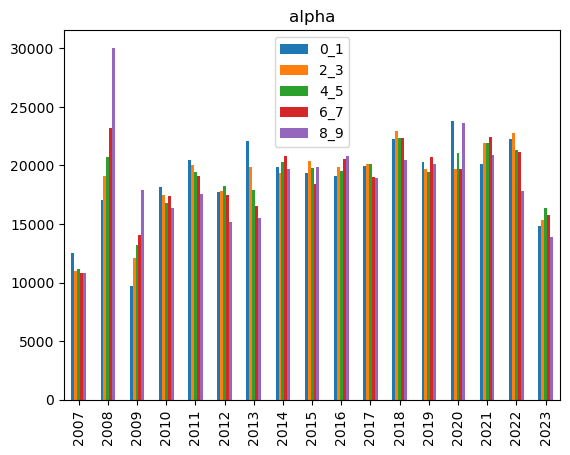

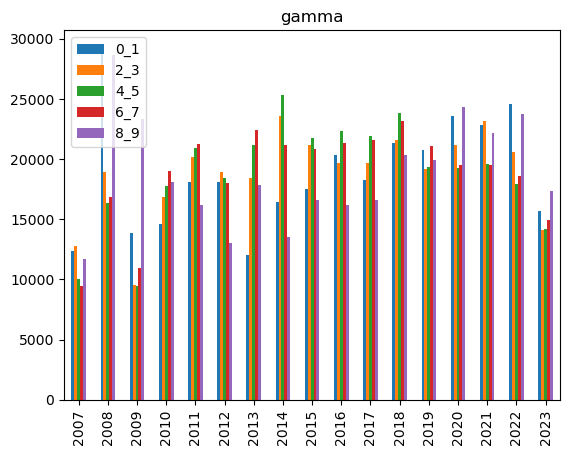

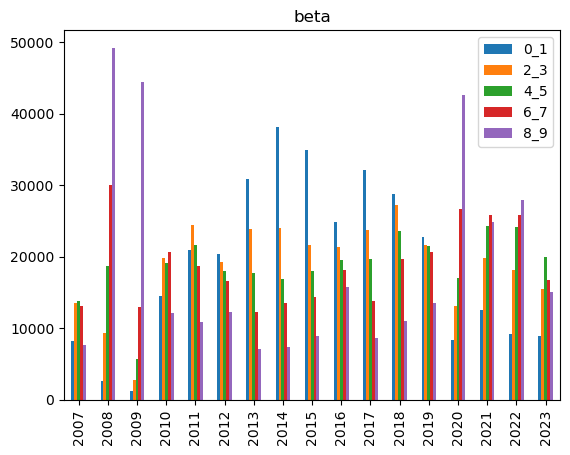

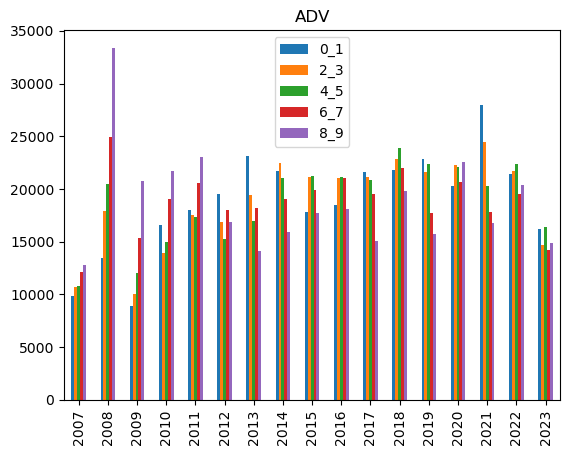

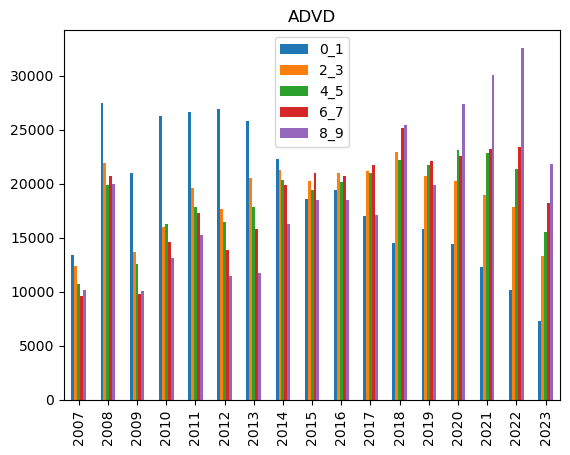

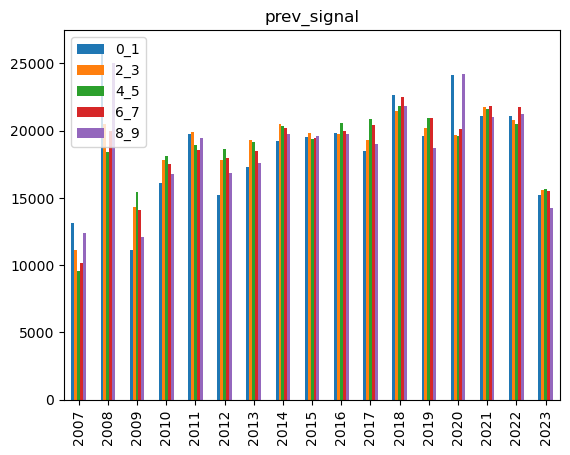

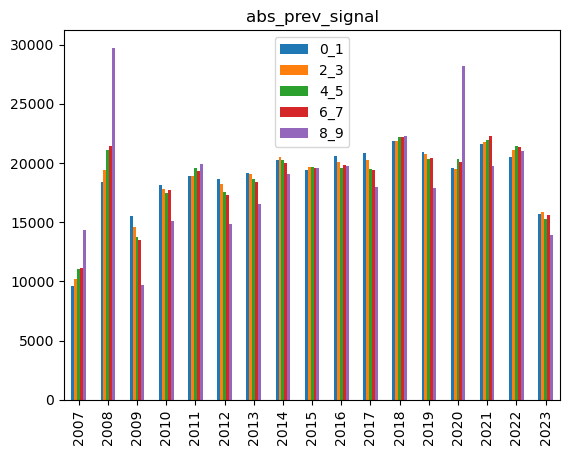

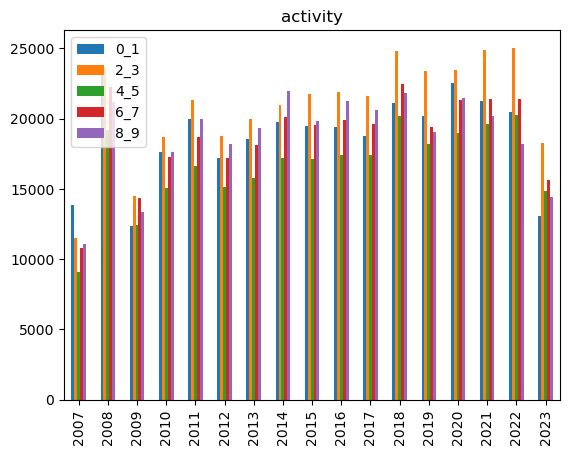

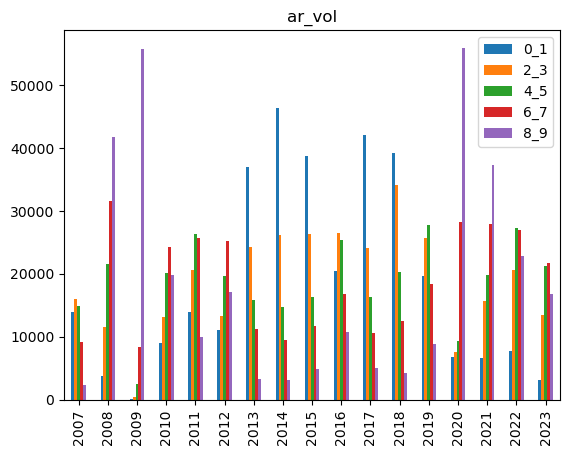

In [7]:
#Demographics by year
for col in  "alpha gamma beta ADV ADVD prev_signal abs_prev_signal activity ar_vol".split():    
    dates = sorted(sim.date.unique())
    df = pd.DataFrame(index=dates)
    groups = [[0,1],[2,3],[4,5],[6,7],[8,9]]
    for g in groups:
            df[ f'{g[0]}_{g[-1]}' ] = sim[ sim[col+'_q'].isin([str(x) for x in g])].groupby('date')['sym'].count()
    df.fillna(0,inplace=True)
    df = df.groupby(df.index.year).sum()
    df.plot.bar(stacked=False,title=col)
    plt.show()
    


In [8]:
features = 'alpha gamma beta ADVD ar_vol pos len_date'.split()
df = byTrade
X = df[features]
Y = df['ew_return']
#ct = make_column_transformer( (OneHotEncoder(),['strategy']),remainder="passthrough")
rf = RandomForestRegressor(n_estimators=100,max_depth=4,verbose=True)
#pipe = make_pipeline(ct,rf)
pipe = make_pipeline(rf)
pipe.fit(X,Y)
#rf.fit(X,Y)
from sklearn.metrics import r2_score
print(f'R2 score {r2_score(Y, pipe.predict(X))} ') 

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  2.2min
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    1.1s


R2 score 0.3643862920783514 


In [9]:
from xgboost import XGBRegressor
#features = 'alpha gamma beta ADVD ar_vol'.split()
X = df[features]
Y = df['ew_return']
#ct = make_column_transformer( (OneHotEncoder(),['strategy']),remainder="passthrough")
xgr = XGBRegressor(n_estimators=100,max_depth=4)
#pipe = make_pipeline(ct,rf)   
pipe2 = make_pipeline(xgr)
pipe2.fit(X,Y)
#rf.fit(X,Y)
from sklearn.metrics import r2_score
print(f'R2 score {r2_score(Y, pipe2.predict(X))} ') 

R2 score 0.43923434874848 


<center> Feature Importance </center>

In [10]:
#fn = ct.get_feature_names_out()
fn = features
fi_df = pd.DataFrame({'feature':fn,'importanceRF':rf.feature_importances_,'importanceXG':xgr.feature_importances_})
fi_df.sort_values('importanceRF', ascending=False,inplace=True)
display(fi_df)



,feature,importanceRF,importanceXG
6,len_date,0.550764,0.408117
5,pos,0.356479,0.407316
2,beta,0.090821,0.104208
4,ar_vol,0.001932,0.040575
1,gamma,0.000003,0.016206
0,alpha,0.000000,0.008446
3,ADVD,0.000000,0.015132


ALPHA(BPS) for alpha vs gamma


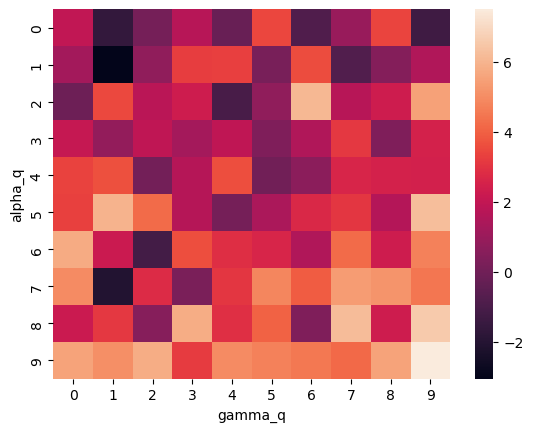

gamma_q     0     1     2    3     4    5     6     7    8     9
alpha_q                                                         
0        1.96 -1.63  0.11 1.71 -0.22 3.46 -0.84  0.95 3.41 -1.32
1        1.23 -3.06  0.75 3.25  3.27 0.17  3.55 -0.81 0.46  1.53
2       -0.12  3.47  1.80 2.27 -1.07 0.75  6.09  1.71 2.28  5.49
3        2.07  0.82  1.91 1.25  1.90 0.36  1.54  3.10 0.33  2.50
4        3.35  3.64  0.06 1.65  3.59 0.03  0.64  2.62 2.51  2.46
5        3.33  5.98  4.25 1.68  0.09 1.44  2.72  3.06 1.62  6.25
6        5.74  2.21 -1.18 3.60  2.86 2.61  1.55  4.22 2.27  4.74
7        4.99 -2.07  2.79 0.21  3.09 4.85  3.89  5.39 5.18  4.48
8        2.20  3.12  0.52 5.79  2.91 4.03  0.34  6.20 2.30  6.58
9        5.54  5.06  5.81 3.19  4.98 4.72  4.52  4.17 5.54  7.51
COUNTS for alpha_q vs gamma_q
gamma_q      0      1      2      3      4      5      6      7      8      9
alpha_q                                                                      
0        12064  11274  11147  1082

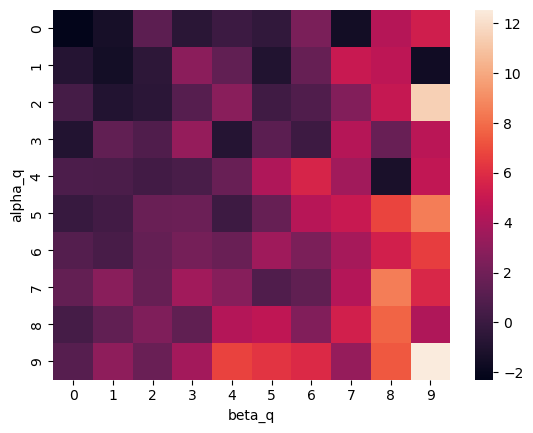

beta_q      0     1     2     3     4     5    6     7     8     9
alpha_q                                                           
0       -2.29 -1.42  1.25 -0.65  0.04 -0.35 2.29 -1.59  4.35  5.30
1       -0.80 -1.53 -0.54  2.88  1.47 -1.01 1.62  5.01  4.61 -1.60
2        0.39 -0.91 -0.57  1.03  2.85  0.21 0.79  2.61  4.92 11.44
3       -0.92  1.45  0.81  3.23 -0.82  1.23 0.11  4.33  1.70  4.49
4        0.69  0.61  0.28  0.56  1.70  4.09 5.63  3.62 -1.25  4.75
5       -0.11  0.28  1.75  1.77  0.14  1.59 4.39  5.02  6.79  8.54
6        1.01  0.50  1.58  2.12  1.71  3.58 2.37  3.84  5.40  6.56
7        1.50  2.81  1.62  3.67  2.74  0.81 1.39  4.27  8.52  5.75
8        0.38  1.44  2.49  1.40  4.30  4.67 2.54  5.39  7.71  4.12
9        1.05  3.03  1.72  3.69  6.70  6.23 5.85  3.21  7.38 12.54
COUNTS for alpha_q vs beta_q
beta_q       0      1      2      3      4      5      6      7      8      9
alpha_q                                                                      
0        10

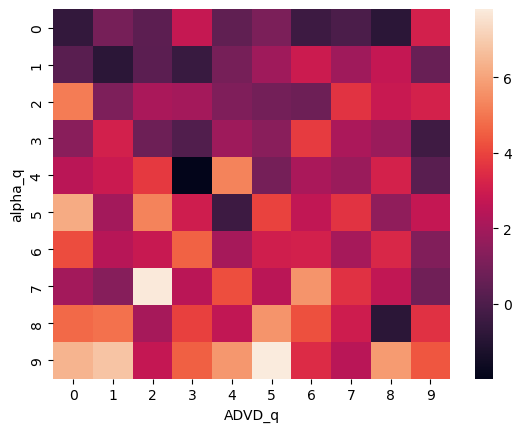

ADVD_q      0     1    2     3     4    5     6     7     8     9
alpha_q                                                          
0       -0.68  0.97 0.35  2.78  0.44 1.08 -0.39 -0.04 -0.87  3.11
1        0.28 -0.85 0.34 -0.51  0.98 1.88  2.93  1.90  2.73  0.64
2        5.10  1.13 2.13  2.03  1.18 0.89  0.74  3.61  2.84  3.15
3        1.39  3.11 0.75  0.11  1.87 1.40  3.80  2.15  1.79 -0.37
4        2.51  2.88 3.78 -1.99  5.26 0.95  2.13  1.77  3.14  0.28
5        6.17  1.99 5.26  3.01 -0.40 3.96  2.65  3.62  1.54  2.73
6        4.17  2.42 2.80  4.59  2.05 3.05  3.12  2.03  3.30  1.22
7        1.99  1.31 7.75  2.52  4.18 2.51  5.66  3.59  2.66  0.82
8        4.72  4.90 2.07  3.91  2.66 5.67  4.24  2.96 -0.84  3.58
9        6.43  6.81 2.73  4.53  5.72 7.81  3.44  2.49  5.80  4.36
COUNTS for alpha_q vs ADVD_q
ADVD_q       0      1      2      3      4      5      6      7      8      9
alpha_q                                                                      
0         9870  10589  

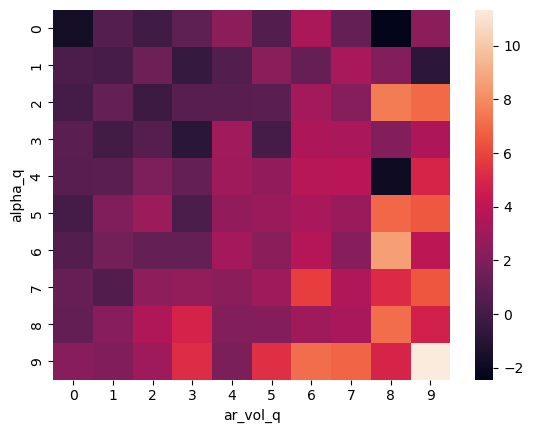

ar_vol_q     0    1     2     3    4    5    6    7     8     9
alpha_q                                                        
0        -1.70 0.59 -0.09  0.94 2.39 0.52 3.39 1.14 -2.44  2.36
1         0.32 0.14  1.40 -0.48 0.49 2.31 1.17 3.29  2.15 -0.80
2         0.07 1.14 -0.28  0.76 0.75 0.81 3.21 2.19  7.54  7.02
3         0.79 0.00  0.65 -0.92 3.08 0.06 3.45 3.28  2.16  3.45
4         0.76 0.84  1.94  1.11 2.94 2.57 3.79 3.82 -1.95  4.90
5         0.07 1.98  2.90  0.29 2.58 2.87 3.30 2.87  6.95  6.52
6         0.56 1.60  1.13  1.13 3.21 2.30 3.74 2.26  8.63  3.99
7         1.20 0.43  2.48  2.63 2.30 3.00 5.75 3.58  5.12  6.47
8         1.07 2.29  3.49  4.84 2.10 2.18 3.02 3.26  7.13  4.73
9         2.29 2.08  3.03  5.21 1.91 5.35 7.11 6.85  4.88 11.34
COUNTS for alpha_q vs ar_vol_q
ar_vol_q      0      1      2      3      4      5      6      7      8      9
alpha_q                                                                       
0         10879  10243  10187  10572  10261

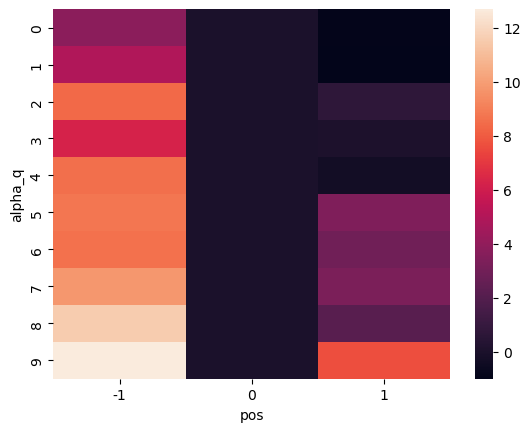

pos        -1    0     1
alpha_q                 
0        3.80 0.00 -0.92
1        4.98 0.00 -1.00
2        8.39 0.00  0.68
3        6.27 0.00  0.03
4        8.53 0.00 -0.31
5        8.74 0.00  3.40
6        8.58 0.00  2.93
7        9.81 0.00  3.32
8       11.53 0.00  2.12
9       12.70 0.00  7.62
COUNTS for alpha_q vs pos
pos         -1      0      1
alpha_q                     
0        26308  52337  25902
1        26370  52275  25892
2        26171  52301  26074
3        26293  52302  25947
4        26393  52320  25826
5        26133  52244  26169
6        26110  52279  26153
7        26222  52239  26078
8        26361  52278  25899
9        26094  52203  26244
ALPHA(BPS) for alpha vs len_date


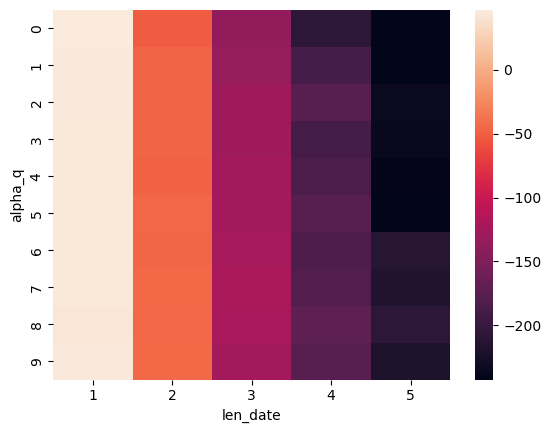

len_date     1      2       3       4       5
alpha_q                                      
0        46.66 -51.63 -137.38 -207.74 -242.40
1        44.69 -47.80 -133.99 -188.75 -241.55
2        44.71 -48.17 -129.27 -176.50 -235.48
3        44.14 -48.12 -127.35 -189.70 -236.56
4        44.02 -48.41 -126.09 -185.78 -240.26
5        44.01 -45.70 -124.17 -175.17 -241.71
6        43.93 -46.76 -123.13 -183.49 -212.28
7        43.89 -44.68 -120.23 -179.62 -217.52
8        43.11 -45.81 -122.03 -172.37 -208.22
9        44.55 -44.73 -125.07 -175.07 -219.26
COUNTS for alpha_q vs len_date
len_date     1      2     3     4     5    6    7    8    9   10  11  12  13   
alpha_q                                                                        
0         74773  16556  6592  3224  1734  812  410  225   96  58  37  21   4  \
1         74895  16431  6574  3361  1616  814  408  223  106  50  32  14   9   
2         74808  16777  6502  3227  1595  831  379  203  113  51  25  13  12   
3         75049  

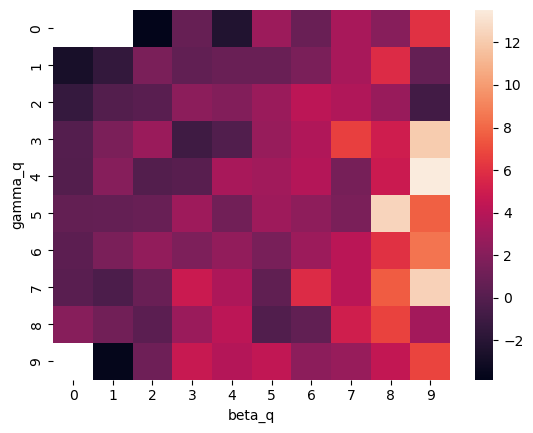

beta_q      0     1     2     3     4     5    6    7     8     9
gamma_q                                                          
0         NaN   NaN -3.84  0.75 -2.34  2.89 0.88 3.40  2.12  6.04
1       -2.71 -1.49  1.54  0.55  0.85  0.88 1.58 3.41  5.79  0.70
2       -1.35 -0.07  0.21  2.29  1.92  2.82 4.20 3.74  2.75 -0.79
3       -0.03  1.60  2.85 -0.95 -0.16  2.68 3.73 6.56  4.99 12.08
4       -0.09  2.00 -0.05  0.14  3.35  3.09 3.87 1.40  4.78 13.52
5        0.63  0.69  0.84  2.98  1.24  2.99 2.36 1.54 12.50  7.72
6        0.31  1.54  2.49  1.66  2.48  1.47 2.93 4.11  6.04  8.49
7        0.19 -0.32  0.85  4.80  3.62  0.46 5.76 4.15  7.58 12.30
8        2.10  1.21  0.27  2.86  4.20 -0.12 0.56 5.09  6.72  3.21
9         NaN -3.66  1.10  4.69  3.85  4.40 2.28 2.74  4.47  6.76
COUNTS for gamma_q vs beta_q
beta_q       0      1      2      3      4      5      6      7      8      9
gamma_q                                                                      
0          127    865  

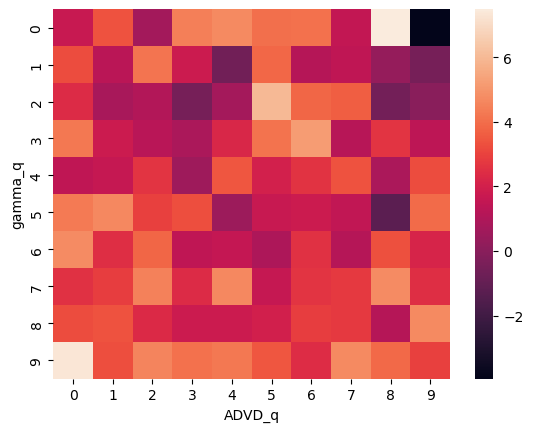

ADVD_q     0    1    2     3     4    5    6    7     8     9
gamma_q                                                      
0       1.65 3.34 0.67  4.44  4.70 4.02 4.06 1.54  7.49 -3.96
1       3.21 1.30 4.17  1.79 -0.61 3.83 1.17 1.44  0.31 -0.49
2       2.35 0.80 1.06 -0.50  0.72 5.98 3.80 3.63 -0.60 -0.01
3       4.25 1.80 1.27  0.91  2.24 4.14 5.19 1.19  2.62  1.40
4       1.45 1.61 2.64  0.54  3.42 2.00 2.58 3.36  0.88  3.21
5       4.28 4.67 2.94  3.26  0.49 1.63 1.79 1.46 -1.23  3.93
6       4.72 2.44 3.79  1.45  1.56 0.96 2.57 1.16  3.31  2.13
7       2.56 2.86 4.45  2.37  4.67 1.63 2.63 2.77  4.72  2.47
8       3.24 3.36 2.31  1.80  1.78 1.96 2.87 2.78  1.16  4.69
9       7.34 3.27 4.55  4.09  4.27 3.44 2.43 4.69  3.87  2.97
COUNTS for gamma_q vs ADVD_q
ADVD_q       0      1      2      3      4      5      6      7      8      9
gamma_q                                                                      
0        13304  11418  11288  11824  11839  10616   9500   9148   8524 

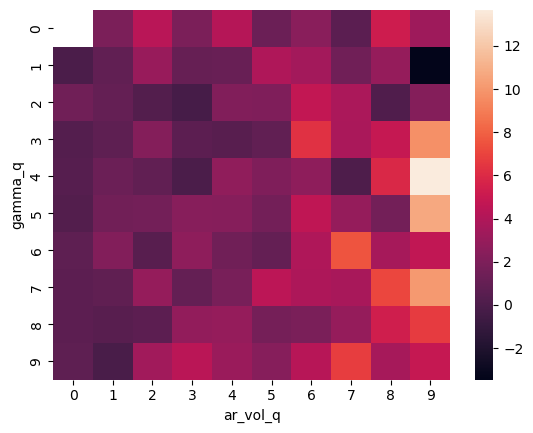

ar_vol_q     0     1    2     3    4    5    6    7    8     9
gamma_q                                                       
0          NaN  1.94 4.31  1.92 4.21 1.28 2.49 0.61 5.19  3.29
1        -0.11  0.88 3.06  1.08 1.11 3.96 3.46 1.47 2.96 -3.46
2         1.44  0.99 0.24 -0.31 2.12 2.06 4.72 3.78 0.10  2.28
3         0.31  0.70 2.26  0.65 0.48 0.85 6.28 3.72 4.87  9.74
4         0.36  1.27 0.85 -0.08 2.70 2.09 2.64 0.06 5.88 13.67
5         0.22  1.51 1.59  2.37 2.34 1.61 4.58 2.95 1.56 10.66
6         0.73  2.22 0.43  2.67 1.48 0.96 3.90 7.57 3.60  4.68
7         0.64  0.81 2.91  0.98 1.77 4.46 3.90 3.68 7.09 10.10
8         0.65  0.43 0.68  2.79 2.95 1.67 1.84 2.93 5.36  6.69
9         0.71 -0.18 3.38  4.38 3.10 2.35 4.25 6.77 3.61  4.85
COUNTS for gamma_q vs ar_vol_q
ar_vol_q      0      1      2      3      4      5      6      7      8      9
gamma_q                                                                       
0           485   1769   3658   6242   8733  11626  132

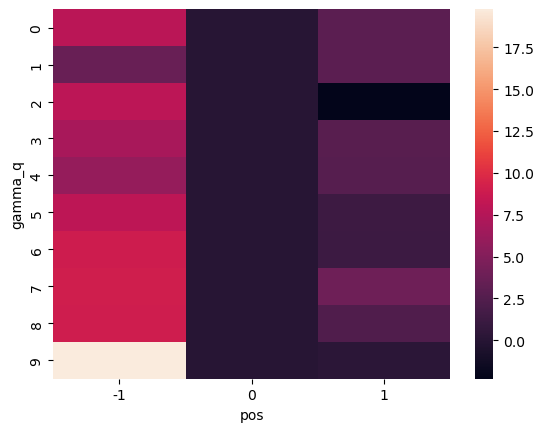

pos        -1    0     1
gamma_q                 
0        7.81 0.00  2.95
1        3.59 0.00  2.92
2        7.96 0.00 -2.29
3        6.90 0.00  2.72
4        5.91 0.00  2.69
5        8.02 0.00  1.32
6        8.87 0.00  1.20
7        9.01 0.00  3.98
8        8.95 0.00  2.31
9       19.79 0.00  0.27
COUNTS for gamma_q vs pos
pos         -1      0      1
gamma_q                     
0        31436  52303  20806
1        29833  52254  22452
2        29021  52262  23260
3        27949  52265  24328
4        26987  52238  25321
5        25821  52281  26434
6        24644  52340  27558
7        23687  52278  28579
8        22343  52323  29872
9        20734  52234  31574
ALPHA(BPS) for gamma vs len_date


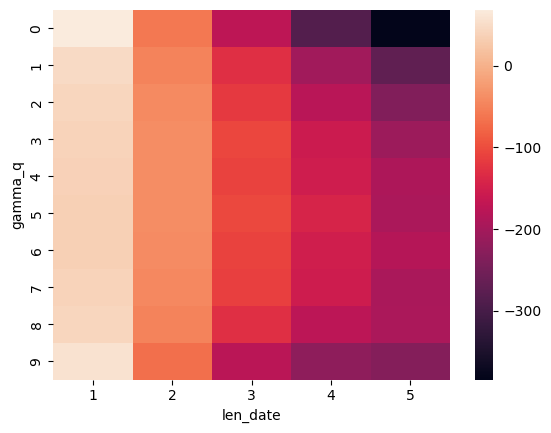

len_date     1      2       3       4       5
gamma_q                                      
0        68.34 -60.33 -172.54 -286.53 -384.42
1        48.62 -49.57 -128.83 -203.65 -271.42
2        41.93 -43.01 -118.73 -178.12 -236.65
3        38.62 -39.44 -106.66 -156.34 -209.15
4        37.25 -38.56 -109.60 -153.67 -191.51
5        35.36 -38.68 -104.92 -142.14 -192.07
6        36.47 -41.12 -108.83 -151.98 -181.30
7        38.63 -43.77 -112.31 -156.01 -193.50
8        42.31 -49.24 -129.10 -175.10 -193.07
9        56.49 -68.39 -176.20 -222.33 -233.75
COUNTS for gamma_q vs len_date
len_date     1      2     3     4     5    6    7    8    9   10  11  12  13   
gamma_q                                                                        
0         74484  16582  6592  3373  1690  865  411  260  138  70  32  21  10  \
1         75039  16382  6517  3213  1660  862  414  203  117  56  37  15   8   
2         75103  16595  6505  3198  1587  790  398  185  105  34  25   7   7   
3         75065  

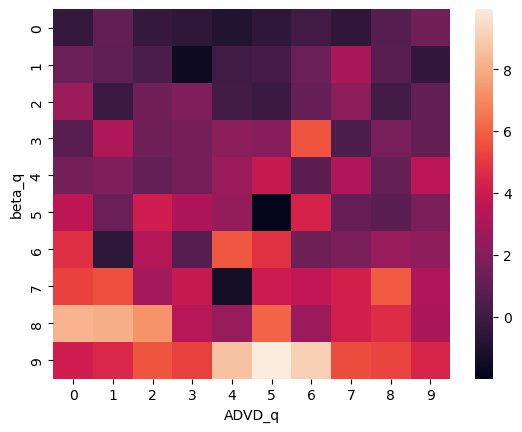

ADVD_q     0     1     2     3     4     5    6     7    8     9
beta_q                                                          
0      -0.33  1.02 -0.33 -0.53 -0.92 -0.54 0.08 -0.47 0.63  1.41
1       1.30  0.90  0.36 -1.61  0.08  0.15 1.29  3.00 0.77 -0.38
2       2.66 -0.18  1.48  1.83  0.12 -0.14 1.17  2.21 0.09  1.02
3       0.73  3.14  1.35  1.53  2.23  2.06 5.69  0.40 1.66  1.07
4       1.50  1.80  1.09  1.50  2.59  3.87 0.88  3.21 1.10  3.48
5       3.56  1.30  4.10  3.13  2.43 -2.00 4.34  1.15 0.80  1.73
6       4.72 -0.58  3.29  0.67  5.77  4.79 1.31  1.70 2.53  2.27
7       5.27  5.51  2.83  3.87 -1.35  3.97 3.67  4.20 5.85  3.18
8       8.18  8.06  7.30  3.37  2.57  6.03 2.58  4.20 4.64  3.00
9       4.08  4.46  5.66  5.16  8.64  9.94 9.10  5.47 5.31  4.43
COUNTS for beta_q vs ADVD_q
ADVD_q      0      1      2      3      4      5      6      7      8      9
beta_q                                                                      
0        7551  10762   9836   8792   8

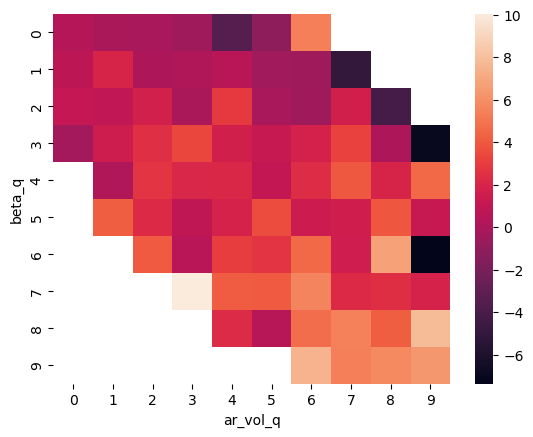

ar_vol_q     0    1     2     3     4     5     6     7     8     9
beta_q                                                             
0         0.38 0.02 -0.11 -0.56 -3.43 -1.17  5.37   NaN   NaN   NaN
1         0.76 1.93  0.09  0.16  0.58 -0.37 -0.49 -4.99   NaN   NaN
2         1.06 0.93  1.72  0.04  2.89 -0.11 -0.51  1.67 -4.23   NaN
3        -0.25 1.44  2.49  3.38  1.64  1.19  1.78  3.22  0.10 -7.00
4          NaN 0.18  2.66  2.06  2.13  1.00  2.33  3.93  1.93  4.54
5          NaN 4.15  2.19  0.81  1.88  3.56  1.35  1.57  3.90  1.19
6          NaN  NaN  4.03  0.58  3.02  2.65  4.54  1.52  6.74 -7.37
7          NaN  NaN   NaN 10.04  4.11  4.04  5.60  2.19  2.39  1.83
8          NaN  NaN   NaN   NaN  2.25  0.48  4.70  5.47  4.16  7.80
9          NaN  NaN   NaN   NaN   NaN   NaN  7.50  5.36  5.76  6.32
COUNTS for beta_q vs ar_vol_q
ar_vol_q      0      1      2      3      4      5      6      7      8      9
beta_q                                                                     

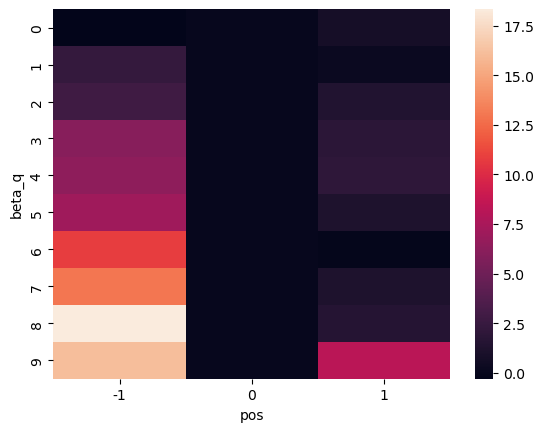

pos       -1    0     1
beta_q                 
0      -0.29 0.00  0.73
1       2.31 0.00  0.26
2       2.80 0.00  1.34
3       6.09 0.00  1.84
4       6.38 0.00  1.99
5       7.07 0.00  1.17
6      10.81 0.00 -0.13
7      12.97 0.00  1.21
8      18.33 0.00  1.55
9      16.13 0.00  8.24
COUNTS for beta_q vs pos
pos        -1      0      1
beta_q                     
0       26097  52337  26113
1       25769  52343  26426
2       25961  52280  26301
3       25968  52332  26241
4       25980  52259  26306
5       26277  52294  25971
6       26199  52261  26081
7       26591  52243  25706
8       26453  52218  25869
9       27160  52211  25170
ALPHA(BPS) for beta vs len_date


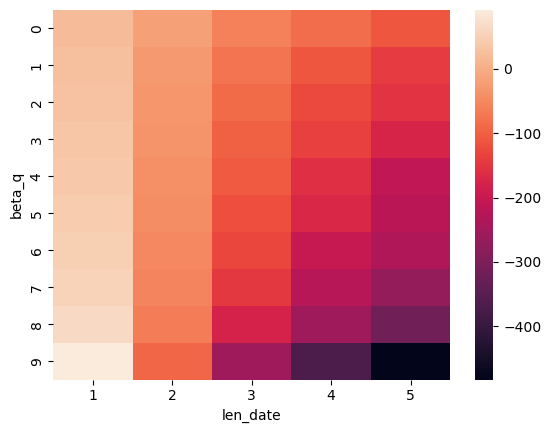

len_date     1      2       3       4       5
beta_q                                       
0        19.64 -20.03  -59.81  -84.20 -112.69
1        25.73 -28.04  -76.24 -110.86 -143.76
2        30.09 -32.57  -87.73 -128.13 -153.96
3        33.96 -36.54 -100.42 -138.56 -176.09
4        37.93 -41.87 -107.73 -158.16 -210.53
5        41.61 -45.50 -121.52 -169.23 -219.35
6        47.03 -50.50 -130.39 -201.08 -234.35
7        53.40 -55.94 -148.69 -224.83 -268.80
8        63.70 -65.64 -179.62 -258.26 -317.41
9        90.85 -93.26 -255.22 -368.16 -482.41
COUNTS for beta_q vs len_date
len_date     1      2     3     4     5    6    7    8    9   10  11  12  13   
beta_q                                                                         
0         74572  17070  6290  3299  1622  822  429  216   99  55  37  19  10  \
1         75256  16369  6313  3211  1683  862  398  220  119  49  37   9   9   
2         75308  16160  6515  3208  1695  840  366  229  110  67  24   9   7   
3         75459  1

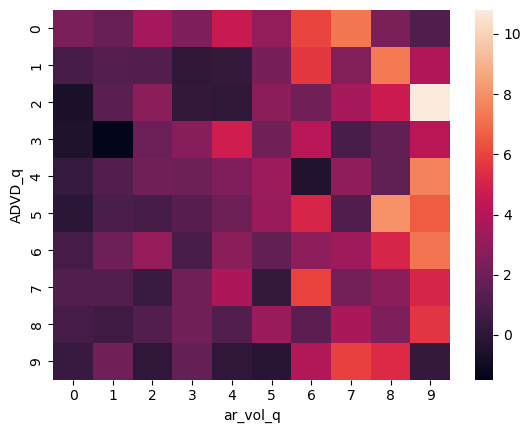

ar_vol_q     0     1    2    3    4     5     6    7    8     9
ADVD_q                                                         
0         2.35  1.82 3.51 2.44 4.59  3.04  6.05 7.32 2.38  1.07
1         0.83  1.22 1.19 0.07 0.21  2.25  5.70 2.64 7.35  3.85
2        -0.66  1.42 2.77 0.17 0.02  2.88  2.07 3.56 4.68 10.79
3        -0.50 -1.48 1.89 2.71 4.77  2.10  4.12 0.90 1.60  4.15
4         0.28  1.20 2.11 1.96 2.50  3.27 -0.41 2.97 1.57  7.60
5        -0.06  0.94 0.81 1.37 1.93  3.22  5.12 1.06 7.97  6.61
6         0.75  1.99 3.15 0.89 2.76  1.60  2.92 3.32 5.13  7.23
7         1.15  1.15 0.43 2.03 3.77  0.21  5.99 2.14 2.85  5.10
8         0.75  0.54 1.11 2.06 1.13  3.24  1.47 3.73 2.40  5.57
9         0.34  2.07 0.09 1.71 0.09 -0.18  3.89 5.86 5.24  0.24
COUNTS for ADVD_q vs ar_vol_q
ar_vol_q      0      1      2      3      4      5      6      7      8      9
ADVD_q                                                                        
0         11072  10911   9290   9170   9664 

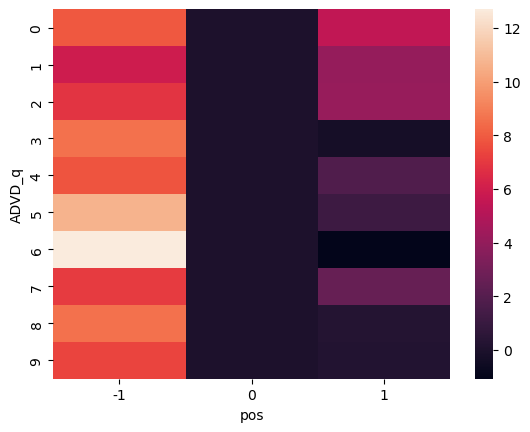

pos       -1    0     1
ADVD_q                 
0       7.90 0.00  5.47
1       5.90 0.00  4.05
2       6.87 0.00  4.11
3       8.56 0.00 -0.30
4       7.77 0.00  1.78
5      10.68 0.00  1.15
6      12.71 0.00 -1.08
7       7.10 0.00  2.56
8       8.57 0.00  0.23
9       7.33 0.00  0.18
COUNTS for ADVD_q vs pos
pos        -1      0      1
ADVD_q                     
0       26634  52448  25460
1       26610  52378  25554
2       26357  52356  25831
3       26313  52323  25903
4       26127  52211  26205
5       26116  52249  26177
6       25889  52225  26426
7       26168  52277  26096
8       26127  52167  26250
9       26114  52144  26282
ALPHA(BPS) for ADVD vs len_date


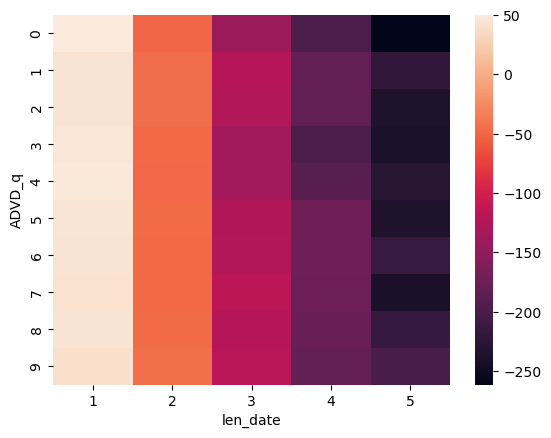

len_date     1      2       3       4       5
ADVD_q                                       
0        50.08 -49.84 -140.00 -199.72 -261.45
1        43.31 -45.57 -123.65 -181.46 -220.43
2        43.53 -46.03 -124.24 -182.95 -235.98
3        46.25 -48.37 -134.49 -199.71 -238.43
4        46.75 -49.19 -134.26 -189.77 -229.29
5        44.95 -46.64 -126.86 -174.28 -236.20
6        43.21 -47.35 -124.32 -173.18 -214.81
7        42.25 -47.52 -117.52 -176.02 -240.01
8        42.91 -47.02 -123.93 -177.22 -216.61
9        40.52 -44.16 -120.08 -180.35 -201.71
COUNTS for ADVD_q vs len_date
len_date     1      2     3     4     5    6    7    8    9   10  11  12  13   
ADVD_q                                                                         
0         74822  16924  6306  3242  1634  807  377  190  111  52  40  15   9  \
1         75575  16064  6347  3185  1598  889  425  237  109  53  32  15   4   
2         75520  16082  6356  3301  1635  809  374  220  117  72  28  16   7   
3         75098  1

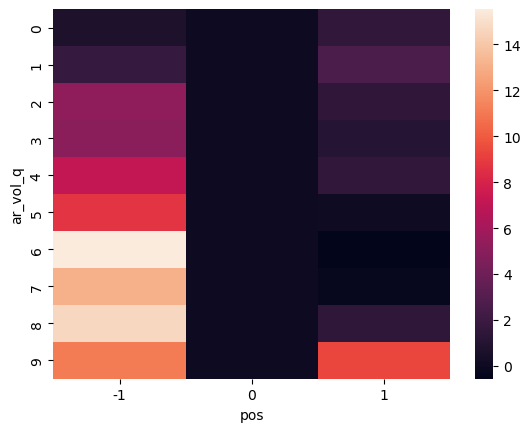

pos         -1    0     1
ar_vol_q                 
0         0.70 0.00  1.53
1         1.75 0.00  2.65
2         5.29 0.00  1.46
3         5.03 0.00  1.04
4         7.12 0.00  1.53
5         8.70 0.00  0.02
6        15.54 0.00 -0.56
7        13.09 0.00 -0.27
8        14.69 0.00  1.42
9        11.12 0.00  9.33
COUNTS for ar_vol_q vs pos
pos          -1      0      1
ar_vol_q                     
0         26172  52347  26023
1         25947  52272  26323
2         25978  52298  26265
3         26227  52288  26027
4         26238  52273  26031
5         26038  52249  26254
6         26146  52328  26068
7         26319  52249  25973
8         26503  52229  25810
9         26887  52245  25410
ALPHA(BPS) for ar_vol vs len_date


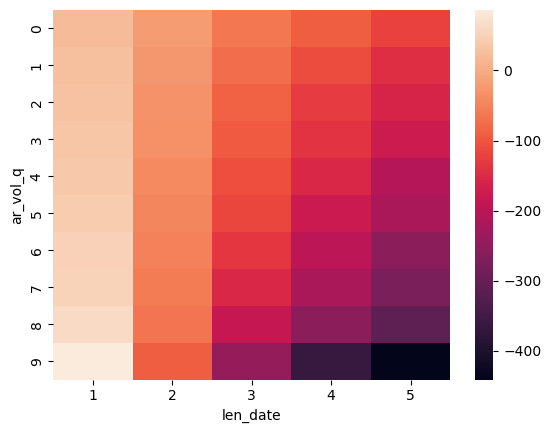

len_date     1      2       3       4       5
ar_vol_q                                     
0        20.83 -19.85  -62.79  -91.48 -119.83
1        26.14 -26.19  -75.93 -110.44 -144.49
2        30.35 -32.01  -87.02 -129.12 -158.89
3        34.11 -34.95  -96.98 -138.98 -177.03
4        38.16 -42.02 -108.45 -153.14 -204.62
5        42.21 -45.86 -117.55 -178.39 -217.83
6        49.61 -51.95 -135.13 -197.46 -255.14
7        53.11 -58.10 -153.55 -216.55 -276.71
8        63.17 -67.30 -183.77 -257.56 -312.00
9        86.19 -92.41 -244.26 -363.35 -440.95
COUNTS for ar_vol_q vs len_date
len_date     1      2     3     4     5    6    7    8    9   10  11  12  13   
ar_vol_q                                                                       
0         74853  16942  6229  3213  1645  845  379  226   97  59  26   8  14  \
1         75323  16231  6385  3309  1639  832  367  193  124  56  43  20  12   
2         75429  16348  6402  3116  1601  791  403  226  115  60  28  17   3   
3         74895 

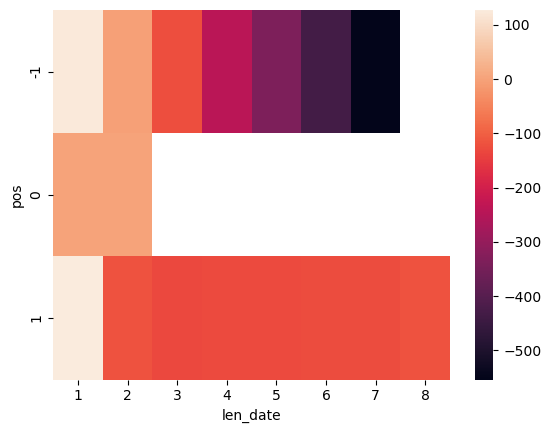

len_date      1       2       3       4       5       6       7       8
pos                                                                    
-1       123.57   -4.08 -122.88 -240.64 -338.11 -433.47 -553.61     NaN
 0         0.00    0.00     NaN     NaN     NaN     NaN     NaN     NaN
 1       127.35 -117.86 -130.91 -129.53 -128.41 -126.13 -125.56 -118.01
COUNTS for pos vs len_date
len_date     1     2     3     4    5    6    7    8   9   10  11  12  13  14   
pos                                                                             
-1       135645 64560 31346 15520 7808 3745 1837  957 535 232 133  59  35  25  \
 0       485342 37436   NaN   NaN  NaN  NaN  NaN  NaN NaN NaN NaN NaN NaN NaN   
 1       130051 64358 32327 16418 8356 4327 2084 1108 539 303 149  84  47  15   

len_date  15  16  17  18  19  
pos                           
-1         7   6   1   4 NaN  
 0       NaN NaN NaN NaN NaN  
 1        12   2   2   1   1  


In [11]:
def meaningful_mean(s:pd.Series) :
    if s is None or len(s) < 1000:
        return np.NaN
    else:
        return s.mean()

#features = 'alpha gamma beta ADVD prev_signal abs_prev_signal activity ar_vol'.split()
#pairwise heat plot of features
#sim['pos_q'] = sim.pos
counter=1
#for f1,f2 in [(a+"_q", b+"_q") for idx, a in enumerate(features) for b in features[idx + 1:]]:
for c1,c2 in [(a, b) for idx, a in enumerate(features) for b in features[idx + 1:]]:   
    print(f'ALPHA(BPS) for {c1} vs {c2}' )
    f1 = c1 if c1 in ['pos','len_date'] else c1+"_q"
    f2 = c2 if c2 in ['pos','len_date'] else c2+"_q"
    hm = pd.pivot_table(byTrade, values='ew_return', index=f1, columns=f2, aggfunc=meaningful_mean)
    hmcounts = pd.pivot_table(byTrade, values='ew_return', index=f1, columns=f2, aggfunc='count')
    with pd.option_context('display.float_format', '{:0.2f}'.format):
        ax = plt.subplot(1,1,1) 
        sns.heatmap(hm*10000,ax=ax)
        counter+=1
        plt.show()
        print(hm*10000)
    with pd.option_context('display.float_format', '{:.0f}'.format):
        print(f'COUNTS for {f1} vs {f2}' )
        print(hmcounts)


OVERALL ALPHA 2.37 bps, CNT 1597769 STD 22.26 STD- 16.58bps STD+ 16.58bps sharpe 0.11 sortino 0.14
ALPHA 5-9 ALPHA 2.95 bps, CNT 798882 STD 22.48 STD- 16.04bps STD+ 16.04bps sharpe 0.13 sortino 0.18
ALPHA 7-9 ALPHA 3.19 bps, CNT 479328 STD 23.78 STD- 16.58bps STD+ 16.58bps sharpe 0.13 sortino 0.19
ALPHA 9-9 ALPHA 3.66 bps, CNT 159760 STD 29.62 STD- 19.49bps STD+ 19.49bps sharpe 0.12 sortino 0.19
BY_TRADE ALPHA 2.21 bps, CNT 1045417 STD 18.00 STD- 13.79bps STD+ 13.79bps sharpe 0.12 sortino 0.16
BY_TRADE 1DAY ALPHA 26.57 bps, CNT 917392 STD 15.62 STD- 8.53bps STD+ 8.53bps sharpe 1.70 sortino 3.11


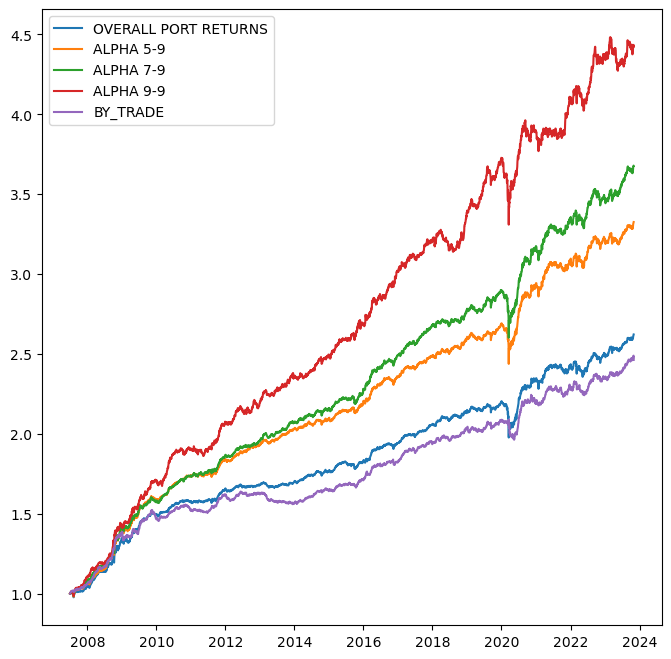

In [12]:
#Overall
def printstats(lbl,trades):
    drets = trades.groupby('date')['ew_return'].mean()
    alpha = drets.mean()
    std = drets.std()
    stdneg = drets[drets<0].std()
    stdpos = drets[drets>=0].std()
    sharpe = alpha/std
    sortino = alpha/stdneg
    
    print(f'{lbl} ALPHA {alpha*10000:.2f} bps, CNT {len(trades):.0f} STD { std*10000:.2f} STD- { stdneg*10000:.2f}bps STD+ { stdneg*10000:.2f}bps sharpe { sharpe:.2f} sortino { sortino:.2f}' )
    
drets = sim.groupby('date')['ew_return'].mean()
printstats('OVERALL', sim)


fig, ax1 = plt.subplots(figsize=(8,8), dpi= 100, facecolor='w', edgecolor='k')
portRets=(1+sim.groupby('date')['ew_return'].mean()).cumprod()
plt.plot(portRets,label='OVERALL PORT RETURNS')
grps = [[5,6,7,8,9],[7,8,9],[9]]
for grp in grps:
    label = f'ALPHA {min(grp)}-{max(grp)}'
    drets = sim[sim.alpha_q.isin([(str(g)) for g in grp])].groupby('date')['ew_return'].mean()
    printstats(label, sim[sim.alpha_q.isin([(str(g)) for g in grp])])
    pi = (1+drets).cumprod()
    plt.plot(pi,label= label)

## Plot byTrade cut, assuming PNL is indexed to the last date
label = 'BY_TRADE'
byTrade['date']=byTrade['last_date']
drets = byTrade.groupby('last_date')['ew_return'].mean()
printstats(label, byTrade)
pi = (1+drets).cumprod()
plt.plot(pi,label= label)

label = 'BY_TRADE 1DAY'
drets = byTrade[byTrade.len_date==1].groupby('last_date')['ew_return'].mean()
printstats(label,  byTrade[byTrade.len_date<=2])
pi = (1+drets).cumprod()
#plt.plot(pi,label= label)

plt.legend()
plt.show()

In [13]:
grp = [9]
drets = byTrade[byTrade.len_date==1].groupby('last_date')['ew_return'].mean()
t = pd.DataFrame()
t['m'] = drets.groupby(drets.index.year).apply( lambda s:(1+s).prod()-1 )
t['s'] = drets.groupby(drets.index.year).std()
t['sharpe'] = t.m/t.s
t
PerspectiveWidget(byTrade[(byTrade.len_date==5)&(byTrade.sym=='A')])
from datetime import date
PerspectiveWidget(sim[ (sim.date.dt.year==2008) &(sim.date.dt.month==10) &(sim.sym=='A') ])
#PerspectiveWidget(byTrade[(sim.trade_id==98)&(sim.sym=='A')])

NameError: name 'PerspectiveWidget' is not defined

In [ ]:
drets=(1+sim.groupby('date')['ew_return'].mean())

with pd.option_context('display.precision', 4, 'display.max_rows', None,'display.float_format', '{:0.4f}'.format):
    #display(drets.resample('M').prod())
    pass
    
memes = sim[(sim.date.dt.year==2020) & ((sim.date.dt.month==3) | (sim.date.dt.month==2))].copy()['sym date adjusted_close c2c factor_c2c excess_c2c prev_signal signal pos ew_return'.split()]
memes = memes[memes.sym=='MFA']
memes['date'] = memes.date.dt.tz_localize('US/Eastern')
table = perspective.Table(memes,index='index')
#view = table.view()
perspective.PerspectiveWidget(table)
#ts=memes['date'].to_list()[0]
#memes.date.dt.tz_localize('US/Eastern')



In [ ]:
#[ts, ts.tz_localize('UTC'),ts.tz_localize('US/Eastern'),ts.tz_localize('UTC').tz_convert('US/Eastern')]

In [ ]:
fig, ax1 = plt.subplots(figsize=(8,8), dpi= 100, facecolor='w', edgecolor='k')
portRets=(1+sim.groupby('date')['ew_return'].mean()).cumprod()
plt.plot(portRets,label='OVERALL PORT RETURNS')
grps = [[0,1,2],[3,4,5,6],[7,8,9]]
for grp in grps:
    pi = (1+sim[sim.ar_vol_q.isin([(str(g)) for g in grp])].groupby('date')['ew_return'].mean()).cumprod()
    plt.plot(pi,label= f'{min(grp)}-{max(grp)}')

optimal = sim[(sim.alpha_q.astype(int)>=7) & (sim.beta_q.astype(int)>=7) & (sim.abs_prev_signal_q.astype(int)>=7)& (sim.activity_q.astype(int)>=7)]
pi = (1+optimal.groupby('date')['ew_return'].mean()).cumprod()
plt.plot(pi,label= f'Optimal')

plt.legend()
plt.title('BY VOL QUANTILES')
plt.show()

In [ ]:
optimal = sim[(sim.alpha_q.astype(int)>=7) & (sim.beta_q.astype(int)>=7) & (sim.abs_prev_signal_q.astype(int)>=7)& (sim.activity_q.astype(int)>=7)]
d=optimal.groupby('date')['ew_return'].mean()
d.sort_values()
import datetime

optimal[optimal['date']==pd.to_datetime(datetime.date(2020,1,23))]
#optimal.date.astype("datetime64[s]")
#pd.to_datetime(datetime.date(2020,1,23))
with pd.option_context('display.max_columns',100):
    display(sim[sim.sym=='SLM'])

In [ ]:
def sharpes(s):
    sh = s.mean()/s.std()
    so = s.mean()/s[s<0].std()
    return sh,so
    
#hiconv trades
grps = [[],[0,1,2],[3,4,5,6,7,8,9],[3,4,5,6],[7,8,9],[9]]
for grp in grps:
    hc = sim[sim.ar_vol_q.isin([(str(g)) for g in grp])] if len(grp) else sim
    print(f'\nGroup {grp} len {len(hc)}')
          
    #hc = sim[sim.TS.isin(['70','80','90'])]
    #winners/losers by trade
    print(f'By trade winners - {len(hc[hc.ew_return>0])} losers {len(hc[hc.ew_return<0])} ')
    bysym = hc.groupby(hc.sym)['ew_return'].mean()
    print(f'By sym winners - {len(bysym[bysym>0])} losers {len(bysym[bysym<0])} ')
    
    bydate = hc.groupby(hc.date)['ew_return'].mean()
    bydatedf = bydate.reset_index()
    print(f'By date winners - {len(bydate[bydate>0])} losers {len(bydate[bydate<0])} sharpe/sort {sharpes(bydate)}')
    #bymonth = hc.groupby(hc.date.dt.to_period("M"))['ew_return'].mean()
    bymonth = bydatedf.reset_index().groupby(bydatedf.date.dt.to_period('M'))['ew_return'].apply(lambda g: (1+g).cumprod().to_list()[-1]-1)
    print(f'By bymonth winners - {len(bymonth[bymonth>0])} losers {len(bymonth[bymonth<0])} sharpe/sort {sharpes(bymonth)}')
    #byq = hc.groupby(hc.date.dt.to_period("Q"))['ew_return'].mean()
    byq = bydatedf.reset_index().groupby(bydatedf.date.dt.to_period('Q'))['ew_return'].apply(lambda g: (1+g).cumprod().to_list()[-1]-1)
    print(f'By byq winners - {len(byq[byq>0])} losers {len(byq[byq<0])} sharpe/sort {sharpes(byq)}')


In [ ]:
#Is there a day of month effect ( which could be because we recalbrate monthly )
bydayOfMonth = sim.groupby(sim['date'].dt.day).agg({'ew_return':[np.mean,np.std,len]})
bydayOfMonth[('ew_return','std_err')] = bydayOfMonth[('ew_return','std')]/np.sqrt(bydayOfMonth[('ew_return','len')])
bydayOfWeek = sim.groupby(sim['date'].dt.dayofweek).agg({'ew_return':[np.mean,np.std,len]})
bydayOfWeek[('ew_return','std_err')] = bydayOfWeek[('ew_return','std')]/np.sqrt(bydayOfWeek[('ew_return','len')])

with pd.option_context('display.float_format', '{:,.4f}'.format):
    print(bydayOfMonth)
    print(bydayOfWeek)

print(bydayOfMonth[('ew_return','mean')].plot.bar())
print(bydayOfWeek[('ew_return','mean')].plot.bar())


In [ ]:
### Dynamic notional allocation scheme that takes into account predicted_tstat_q, ar_vol_q and beta to allocate dollars by trade
def getAllocationWeights(mults:np.ndarray):
    tstatMultipliers,volMultipliers,betaMultipliers,advdMultipliers,abspMultipliers = \
        mults[0:10],mults[10:20],mults[20:30],mults[30:40],mults[40:50]
    PREDICTED_TSTAT_Q_MULTIPLIER = dict(zip([str(x) for x in range(10)],tstatMultipliers))
    AR_VOL_Q_MULTIPLIER = dict(zip([str(x) for x in range(10)],  volMultipliers))
    AR_BETA_Q_MULTIPLIER = dict(zip([str(x) for x in range(10)], betaMultipliers))
    ADVD_Q_MULTIPLIER = dict(zip([str(x) for x in range(10)], advdMultipliers))
    ABS_PRED_Q_MULTIPLIER = dict(zip([str(x) for x in range(10)], abspMultipliers))
    t1 = sim['predicted_tstat_q'].map(PREDICTED_TSTAT_Q_MULTIPLIER).astype(float)
    t2 = sim['ar_vol_q'].map(AR_VOL_Q_MULTIPLIER).astype(float)
    t3 = sim['ar_beta_q'].map(AR_BETA_Q_MULTIPLIER).astype(float)
    t4 = sim['ADVD_q'].map(ADVD_Q_MULTIPLIER).astype(float)
    t5 = sim['abs_predicted_c2cdn_q'].map(ABS_PRED_Q_MULTIPLIER).astype(float)
    score = t1*t2*t3*t5*t5
    dailyScore = score.groupby(sim.date).sum()
    dailyScore.name='dailyScore'
    allocationWeight=score/sim.merge(dailyScore, on='date',how='left')['dailyScore']
    return allocationWeight
    
GLOBAL_COUNTER=0
def getSortino(mults:np.ndarray,verbose=False)->int:
    #print(f'Invoked with {mults}')
    global GLOBAL_COUNTER
    allocationWeight = getAllocationWeights(mults)
    dynamicReturns = (allocationWeight*sim.c2cdn*np.sign(sim.predicted_c2cdn)).groupby(sim.date).sum()
    sortino =  dynamicReturns.mean()/dynamicReturns[dynamicReturns<0].std() #sortino
    sharpe =  dynamicReturns.mean()/dynamicReturns.std() #sharpe
    if verbose or GLOBAL_COUNTER % 100 == 0:
        print( f'{GLOBAL_COUNTER} ALPHA { 10000*dynamicReturns.mean():.2f}bps SORTINO {sortino:.4f} SHARPE {sharpe:.4f}' )
    GLOBAL_COUNTER+=1
    return sortino
        
def getSortinoInverse(mults)->int:
    return 1./getSortino(mults)
    

In [ ]:
#getSharpe([ .2,.2,.2,.2,.2,.5,1.,2.,3.,4.],[ .2,.2,.2,.2,1.,1.,1.,1.,2.,4.])
#getSharpe(np.array([ .2,.2,.2,.2,.2,.5,1.,2.,3.,4., .2,.2,.2,.2,1.,1.,1.,1.,2.,4.]))
from scipy.optimize import minimize
#initialGuess = np.array([ .2,.2,.2,.2,.2,.5,1.,2.,3.,4., .2,.2,.2,.2,1.,1.,1.,1.,2.,4.])
initialGuess = np.array([.1]*50)
bounds = [(0,None) for v in initialGuess]
GLOBAL_COUNTER=0
solution = minimize(getSortinoInverse,tol=0.0001,x0=initialGuess,bounds=bounds,options={'disp':True, 'maxiter':10000})
mults = solution.x
print('TSTAT VOL BETA ADV APRED')
for i in range(10):
    print(f'{mults[i]:.2f} {mults[i+10]:.2f} {mults[i+20]:.2f} {mults[i+30]:.2f} {mults[i+40]:.2f}')


In [ ]:
allocationWeight = getAllocationWeights(solution.x)
dynamicReturns = (allocationWeight*sim.c2cdn*np.sign(sim.predicted_c2cdn)).groupby(sim.date).sum()
#multDR = (1+dynamicReturns)
#multDR.groupby([multDR.index.year,multDR.index.month]).prod().apply([np.mean,np.std])
annualized = dynamicReturns.groupby([dynamicReturns.index.year]).sum() ## No re-investment / compounding
annualized.mean()/annualized.std()


In [ ]:
allocationWeight = getAllocationWeights(solution.x)
allocationWeightLO = allocationWeight[np.sign(sim.predicted_c2cdn)==1]
allocationWeightLO=allocationWeightLO/allocationWeightLO.groupby(sim.date).transform(sum)

allocationWeightSO = allocationWeight[np.sign(sim.predicted_c2cdn)==-1]
allocationWeightSO=allocationWeightSO/allocationWeightSO.groupby(sim.date).transform(sum)

dynamicReturns = (allocationWeight*sim.c2cdn*np.sign(sim.predicted_c2cdn)).groupby(sim.date).sum()
dynamicReturnsLO = (allocationWeightLO*sim.c2cdn*np.sign(sim.predicted_c2cdn)).groupby(sim.date).sum()
dynamicReturnsSO = (allocationWeightSO*sim.c2cdn*np.sign(sim.predicted_c2cdn)).groupby(sim.date).sum()


simpleReturns = (sim.c2cdn*np.sign(sim.predicted_c2cdn)).groupby(sim.date).mean()
fig, ax1 = plt.subplots(figsize=(8,8), dpi= 100, facecolor='w', edgecolor='k')
portRets=(1+sim.groupby('date')['ew_return'].mean()).cumprod()
plt.plot((1+dynamicReturns).cumprod(),label='OPTIMAL SHARPE')
plt.plot((1+dynamicReturnsLO).cumprod(),label='OPTIMAL SHARPE LO')
plt.plot((1+dynamicReturnsSO).cumprod(),label='OPTIMAL SHARPE SO')
plt.plot((1+simpleReturns).cumprod(),label='EVEN WEIGHT')
#High rish strategy
hiRiskTrades = sim[(sim.predicted_tstat_q.astype(float)+sim.ar_vol_q.astype(float))>=16]
hiRiskReturns = hiRiskTrades.groupby('date')['ew_return'].mean()
#plt.plot((1+hiRiskReturns).cumprod(),label='HI RISK')

plt.legend()
plt.show()

In [ ]:
with pd.option_context('display.max_columns', 50):
    display(sim.head())


In [ ]:
allocationWeight = getAllocationWeights(solution.x)

bySim = (np.sign(sim.predicted_c2cdn) * sim.c2cdn).groupby([sim.sym,sim.date.dt.year]).agg( samples=len,rtrn=np.mean )
bySim.sort_values('rtrn',inplace=True)
bySim.to_csv('c:/temp/bysim.csv')

